# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido.

### Objetivos

- estimar futuramente a probabilidade de atraso de cada pedido;
- explicar os principais fatores associados ao risco;
- apoiar uma decisão operacional baseada em custos e capacidade.

> Este notebook não pretende realizar um EDA completo. Ele apresenta uma experiência reduzida e orientada por hipóteses, adequada para uma aula curta.

## Roteiro da experiência

1. Definir o alvo e o instante da previsão.
2. Carregar e verificar as tabelas.
3. Integrar os dados mantendo **uma linha por pedido**.
4. Investigar cinco perguntas orientadas por hipóteses.
5. Registrar conclusões e possíveis features.

**Pergunta central:** quais características disponíveis após a aprovação do pagamento estão associadas ao atraso?

In [1]:
# Bibliotecas para caminhos, manipulação de dados e visualização.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Configura a exibição das tabelas e o estilo dos gráficos.
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="Blues_r")


# Define os caminhos principais do projeto.
ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data"


# Exibe o caminho da pasta onde estão os dados.
DATA_DIR

WindowsPath('C:/Users/vitor/OneDrive/Documentos/VS Code/10semestre/curso-ml-cimatec/olist/data')

## 1. Instante da previsão e risco de data leakage

O modelo deverá gerar a previsão no instante `order_approved_at`. Assim, somente informações já conhecidas até esse momento poderão ser usadas como features.

| Disponível na previsão | Informação futura (não usar como feature) |
|---|---|
| data da compra e aprovação | data de envio à transportadora |
| prazo prometido | data real da entrega |
| cliente e localização | avaliação e comentário do cliente |
| itens, vendedores, preço e frete | status ou eventos posteriores |

> A data real da entrega será utilizada apenas para construir o target. Ela não poderá entrar como variável explicativa do modelo.

## 2. Carregamento das tabelas

Utilizaremos quatro tabelas obrigatórias para o nosso cenário

In [2]:
# Mapeia os nomes dos datasets para seus arquivos CSV.
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

# Lista as colunas que devem ser interpretadas como datas.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# Carrega a base de pedidos, convertendo automaticamente as colunas de data.
orders = pd.read_csv(
    DATA_DIR / "raw" / FILES["orders"],
    parse_dates=date_columns,
)

# Carrega as bases de itens dos pedidos e clientes.
items = pd.read_csv(DATA_DIR / "raw" / FILES["items"])
customers = pd.read_csv(DATA_DIR / "raw" / FILES["customers"])

# Exibe a quantidade de linhas e colunas de cada base carregada.
print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Clientes:", customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Construção do alvo

Para simplificar a experiência, usaremos apenas pedidos com status `delivered` e data real de entrega conhecida.


$$
is\_late = 1 \quad \text{se entrega real > entrega prometida}
$$


In [3]:
# Seleciona apenas os pedidos que podem ser utilizados para construir
# o histórico de entregas atrasadas e realizadas dentro do prazo.
delivered_orders = orders.loc[
    # Mantém somente pedidos que foram efetivamente entregues.
    orders["order_status"].eq("delivered")

    # Remove pedidos sem a data real em que o cliente recebeu a compra.
    # Essa data é necessária para saber se o pedido atrasou.
    & orders["order_delivered_customer_date"].notna()

    # Remove pedidos sem a data de entrega prometida ao cliente.
    # Sem essa informação, não é possível comparar o previsto com o realizado.
    & orders["order_estimated_delivery_date"].notna()

    # Mantém somente pedidos com a data de aprovação do pagamento.
    # Esse é o momento definido para realizar a previsão.
    & orders["order_approved_at"].notna()
].copy()  # Cria uma cópia independente para evitar alterações no DataFrame original.


# Cria a variável-alvo do problema:
# 1 → pedido entregue depois da data prometida;
# 0 → pedido entregue dentro do prazo ou antes da data prometida.
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
).astype("int8")  # Armazena 0 e 1 usando um tipo inteiro que ocupa menos memória.


# Apresenta a quantidade total de pedidos antes da aplicação dos filtros.
print(f"Pedidos originais: {len(orders):,}")


# Apresenta quantos pedidos permaneceram após aplicação do filtro
print(f"Pedidos filtrados: {len(delivered_orders):,}")


# Mostra a quantidade de pedidos em cada classe:
# 0 = entregue no prazo;
# 1 = entregue com atraso.
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)

Pedidos originais: 99,441
Pedidos filtrados: 96,456


is_late
0    88630
1     7826
Name: count, dtype: int64

## 4. Integração no nível do pedido

A tabela de itens tem várias linhas para o mesmo pedido. Antes do `merge`, precisamos agregá-la. Caso contrário, a unidade de análise deixaria de ser o pedido e alguns pedidos teriam peso maior simplesmente por possuírem mais itens.

### 4.1 Agregação

In [4]:
# A tabela de itens possui uma linha para cada item presente no pedido.
# Portanto, um mesmo order_id pode aparecer várias vezes.
#
# Como o objetivo é construir uma base com uma linha por pedido,
# precisamos agrupar os itens antes de integrar essa tabela às demais.
items_agg = (
    items.groupby(
        "order_id",       # Agrupa todos os itens pertencentes ao mesmo pedido.
        as_index=False,   # Mantém order_id como uma coluna comum.
    )
    .agg(
        # Conta quantas linhas de itens existem em cada pedido.
        # Um pedido com três produtos registrados terá item_count igual a 3.
        # nome_da_nova_coluna=("coluna_original", "função")
        item_count=("order_item_id", "count"),

        # Conta quantos vendedores diferentes participam do pedido.
        # O nunique evita contar o mesmo vendedor mais de uma vez.
        # nome_da_nova_coluna=("coluna_original", "função")
        seller_count=("seller_id", "nunique"),

        # Soma os preços dos itens para obter o valor total dos produtos
        # presentes no pedido.
        # nome_da_nova_coluna=("coluna_original", "função")
        total_price=("price", "sum"),

        # Soma o frete de todos os itens para obter o valor total de frete
        # associado ao pedido.
        total_freight=("freight_value", "sum"),
    )
)


# Verifica se cada pedido aparece somente uma vez após a agregação.
#
# Se a condição for falsa, o Python interromperá a execução e lançará
# um AssertionError. Essa checagem ajuda a garantir que a unidade de
# análise da nova tabela é realmente o pedido.
assert items_agg["order_id"].is_unique


# Exibe as cinco primeiras linhas da tabela agregada.
items_agg.head()

,order_id,item_count,seller_count,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


### 4.2 Merge

In [5]:
# Começa com os pedidos entregues que possuem as datas necessárias
# para determinar se houve atraso.
orders_analysis = (
    delivered_orders

    # Adiciona as informações agregadas dos itens:
    # quantidade de itens, vendedores, preço total e frete total.
    .merge(
        items_agg,
        on="order_id",            # Coluna usada para relacionar as tabelas.
        how="left",               # Mantém todos os pedidos de delivered_orders.
        validate="one_to_one",    # Verifica se order_id é único nas duas tabelas.
    )

    # Adiciona a localização do cliente.
    .merge(
        customers[
            ["customer_id", "customer_state", "customer_city",]
        ],
        on="customer_id",         # Relaciona cada pedido ao seu cliente.
        how="left",               # Mantém todos os pedidos da base anterior.
        validate="many_to_one",   # Vários pedidos podem apontar para um cliente.
    )
)

assert orders_analysis["order_id"].is_unique, "A base final deve manter uma linha por pedido."
assert len(orders_analysis) == len(delivered_orders), "A integração alterou o total de pedidos."

print("Dimensão da base analítica:", orders_analysis.shape)
orders_analysis.head()

Dimensão da base analítica: (96456, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre


## 5. Criação de Novas Variáveis

Estas variáveis são construídas apenas com dados conhecidos até a aprovação do pagamento.

In [6]:
# Calcula quantos dias a empresa prometeu para realizar a entrega,
# considerando como início o momento da aprovação do pagamento.
orders_analysis["promised_days"] = (
    orders_analysis["order_estimated_delivery_date"]  # Data prometida para a entrega.
    - orders_analysis["order_approved_at"]            # Data de aprovação do pagamento.
).dt.total_seconds().div(86_400)          # Converte segundos para dias => 24 * 60 * 60 = 86.400 segundos


# Extrai o número do mês em que a compra foi realizada.
# Exemplo: janeiro = 1, fevereiro = 2, ..., dezembro = 12.
orders_analysis["purchase_month"] = (
    orders_analysis["order_purchase_timestamp"].dt.month
)


# Extrai o dia da semana em que a compra foi realizada.
#
# O Pandas representa os dias da seguinte forma:
# 0 = segunda-feira
# 1 = terça-feira
# 2 = quarta-feira
# 3 = quinta-feira
# 4 = sexta-feira
# 5 = sábado
# 6 = domingo
orders_analysis["purchase_weekday"] = (
    orders_analysis["order_purchase_timestamp"].dt.dayofweek
)


# Extrai a hora em que a compra foi realizada.
# Os valores variam de 0 a 23.
#
# Exemplo:
# 0  = meia-noite
# 8  = 8 horas
# 14 = 14 horas
# 23 = 23 horas
orders_analysis["purchase_hour"] = (
    orders_analysis["order_purchase_timestamp"].dt.hour
)


# Gera estatísticas descritivas para o prazo prometido:
# quantidade, média, desvio-padrão, mínimo, quartis e máximo.
#
# describe() gera as estatísticas.
# to_frame() transforma o resultado em DataFrame.
# .T transpõe a tabela para que as estatísticas apareçam como colunas.
display(
    orders_analysis["promised_days"].describe().to_frame().T
)


# Conta quantos pedidos apresentam prazo prometido menor ou igual a zero.
#
# Esses casos seriam suspeitos porque significariam que a data prometida
# ocorreu antes ou exatamente no momento da aprovação do pagamento.
print(
    "Prazos não positivos:",
    orders_analysis["promised_days"].le(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
promised_days,96456.0,23.306482,8.765103,-6.664225,17.905885,22.668762,28.066727,153.57603


Prazos não positivos: 6


# Pergunta 1: Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

**Discussão:** se um modelo sempre previsse “não atrasará”, qual seria sua acurácia? Ela seria suficiente para avaliar o modelo?

Taxa de atraso: 8.11%


,proporcao
is_late,
0,0.918865
1,0.081135


C:\Users\vitor\AppData\Local\Temp\ipykernel_25240\232132611.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No prazo (0)", "Atrasado (1)"])


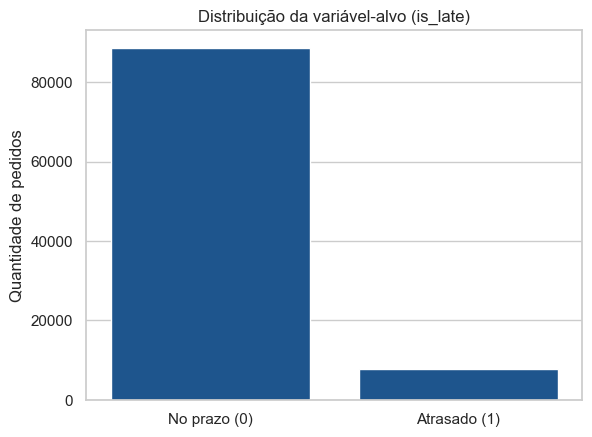

In [7]:
# Taxa de atraso geral (proporção da classe positiva).
late_rate = orders_analysis["is_late"].mean()

print(f"Taxa de atraso: {late_rate:.2%}")

# Frequência absoluta e relativa de cada classe.
display(
    orders_analysis["is_late"]
    .value_counts(normalize=True)
    .rename("proporcao")
    .to_frame()
)

# Visualiza o desbalanceamento entre as classes.
ax = sns.countplot(data=orders_analysis, x="is_late")
ax.set_xticklabels(["No prazo (0)", "Atrasado (1)"])
ax.set_title("Distribuição da variável-alvo (is_late)")
ax.set_xlabel("")
ax.set_ylabel("Quantidade de pedidos")
plt.show()

**Conclusão da pergunta 1:**

- Taxa de atraso: `8.11%` (7.826 de 96.456 pedidos entregues estão atrasados).
- A hipótese foi apoiada? `Sim` — as classes são bastante desbalanceadas (~92% no prazo vs ~8% atrasados).
- Implicação para a modelagem: um modelo que sempre previsse "não atrasará" teria acurácia de ~91.9%, mas seria inútil na prática (recall = 0 para atrasos). É necessário usar métricas sensíveis ao desbalanceamento, como recall, precisão, F1 ou AUC, além de considerar técnicas de balanceamento (`class_weight`, oversampling, etc.) no treinamento.

# Pergunta 2: Pedidos com prazos menores atrasam mais?

**Hipótese:** quando a empresa promete entregar em poucos dias, existe menos
margem para problemas logísticos e o pedido pode apresentar maior risco de atraso.


,taxa_atraso,n_pedidos
promised_days_bin,,
0-7,0.283445,1637
8-14,0.067644,11531
15-21,0.090729,25185
22-28,0.085197,33757
29+,0.058275,24333


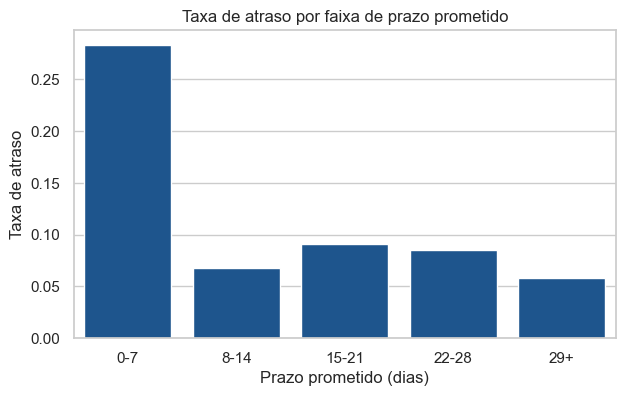

In [8]:
# Cria faixas de prazo prometido (em dias) para comparar a taxa de atraso.
orders_analysis["promised_days_bin"] = pd.cut(
    orders_analysis["promised_days"],
    bins=[0, 7, 14, 21, 28, 100],
    labels=["0-7", "8-14", "15-21", "22-28", "29+"],
)

# Taxa de atraso e quantidade de pedidos em cada faixa de prazo.
q2 = orders_analysis.groupby("promised_days_bin", observed=True)["is_late"].agg(
    taxa_atraso="mean", n_pedidos="size"
)
display(q2)

# Visualiza a taxa de atraso por faixa de prazo prometido.
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=q2.reset_index(), x="promised_days_bin", y="taxa_atraso", ax=ax)
ax.set_xlabel("Prazo prometido (dias)")
ax.set_ylabel("Taxa de atraso")
ax.set_title("Taxa de atraso por faixa de prazo prometido")
plt.show()

**Conclusão da pergunta 2:**

- Pedidos com prazo prometido muito curto (0-7 dias) têm taxa de atraso de `28.3%`, muito acima das demais faixas (entre `5.8%` e `9.1%`).
- Fora dessa faixa extrema, a relação não é monotônica: 8-14 dias (`6.8%`) e 29+ dias (`5.8%`) têm taxa menor que 15-28 dias (`~8.5-9.1%`).
- A faixa de 0-7 dias tem poucas observações (1.637 pedidos, ~1.7% da base) — merece cautela, mas o efeito é grande demais para ser só ruído.
- A hipótese foi parcialmente apoiada: prazos muito curtos aumentam bastante o risco de atraso; para prazos "normais" (8+ dias) o prazo prometido isolado tem pouco poder preditivo (correlação linear de apenas `-0.06`).

# Pergunta 3: Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** pedidos com mais itens ou vendedores apresentam maior complexidade logística e maior risco.

,taxa_atraso,n_pedidos
item_count,,
1,0.082894,86822
2,0.066297,7391
3,0.062021,1306
4,0.056566,495
5,0.067358,193
6,0.083770,191
7,0.000000,22
8,0.000000,8
9,0.000000,3


,taxa_atraso,n_pedidos
multi_seller,,
False,0.082033,95181
True,0.014118,1275


C:\Users\vitor\AppData\Local\Temp\ipykernel_25240\2559824631.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["1 vendedor", "2+ vendedores"])


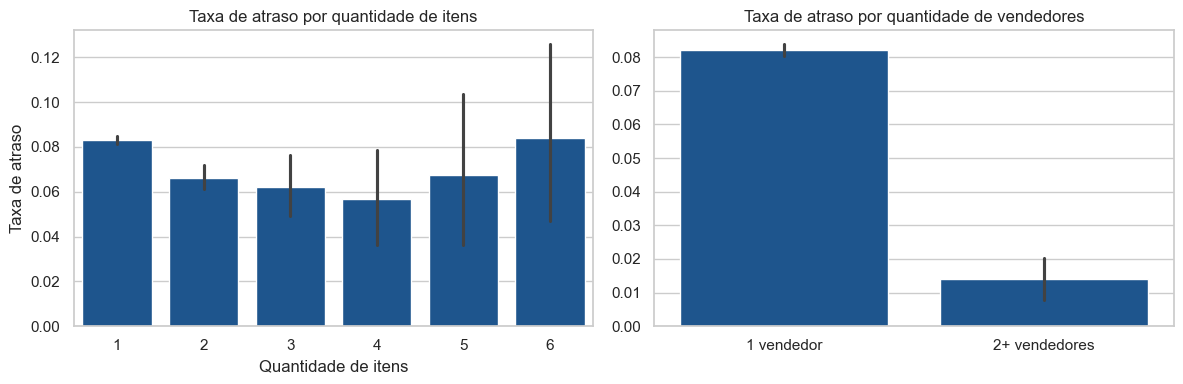

In [9]:
# Taxa de atraso por quantidade de itens no pedido.
q3_items = orders_analysis.groupby("item_count")["is_late"].agg(taxa_atraso="mean", n_pedidos="size")
display(q3_items)

# Taxa de atraso por quantidade de vendedores distintos no pedido
# (agrupado em "1 vendedor" vs "2+ vendedores" para ter volume suficiente em cada grupo).
orders_analysis["multi_seller"] = orders_analysis["seller_count"].gt(1)
q3_sellers = orders_analysis.groupby("multi_seller")["is_late"].agg(taxa_atraso="mean", n_pedidos="size")
display(q3_sellers)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=orders_analysis[orders_analysis["item_count"] <= 6],
    x="item_count", y="is_late", ax=axes[0],
)
axes[0].set_title("Taxa de atraso por quantidade de itens")
axes[0].set_xlabel("Quantidade de itens")
axes[0].set_ylabel("Taxa de atraso")

sns.barplot(data=orders_analysis, x="multi_seller", y="is_late", ax=axes[1])
axes[1].set_xticklabels(["1 vendedor", "2+ vendedores"])
axes[1].set_title("Taxa de atraso por quantidade de vendedores")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Conclusão da pergunta 3:**

- `item_count`: a taxa de atraso não cresce de forma consistente com o número de itens (varia entre `~5.7%` e `8.4%` até 6 itens; acima disso o volume de pedidos é pequeno demais — menos de 25 casos por valor — para confiar no número).
- `seller_count`: o resultado é o **oposto** da hipótese. Pedidos com múltiplos vendedores têm taxa de atraso muito menor (`1.4%`) do que pedidos de vendedor único (`8.2%`).
- As diferenças não parecem operacionalmente relevantes para `item_count`, mas são grandes para `seller_count` — só que na direção contrária à esperada.
- A hipótese de complexidade não foi apoiada como esperado. Uma explicação plausível é que pedidos multi-vendedor são uma fração pequena da base (~1,3%) e podem vir de operações mais profissionalizadas (marketplaces com SLA melhor), não necessariamente mais simples logisticamente — vale investigar melhor antes de usar como feature.

# Pergunta 4: O risco varia geograficamente?

**Hipótese:** alguns estados apresentam maior risco devido à distância ou à infraestrutura logística.

Para evitar conclusões instáveis, mostraremos apenas estados com pelo menos 100 pedidos no recorte.

,taxa_atraso,n_pedidos
customer_state,,
AL,0.239295,397
MA,0.196927,716
PI,0.159664,476
CE,0.153365,1278
SE,0.152239,335
BA,0.140356,3256
RJ,0.134759,12348
TO,0.127737,274
PA,0.123679,946


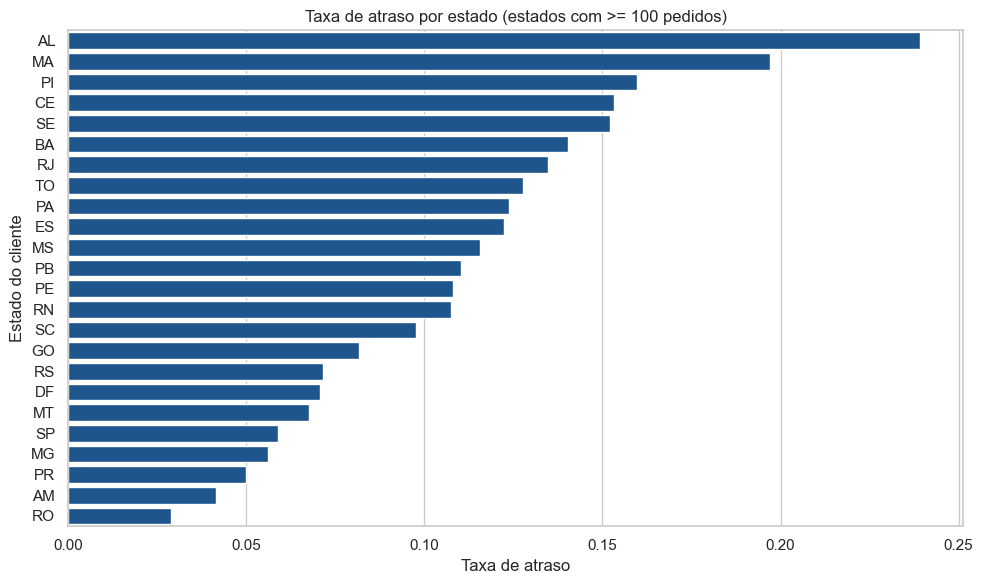

In [10]:
# Mantém apenas estados com pelo menos 100 pedidos no recorte, para evitar
# taxas instáveis calculadas sobre poucas observações.
state_counts = orders_analysis["customer_state"].value_counts()
valid_states = state_counts[state_counts.ge(100)].index

q4 = (
    orders_analysis[orders_analysis["customer_state"].isin(valid_states)]
    .groupby("customer_state")["is_late"]
    .agg(taxa_atraso="mean", n_pedidos="size")
    .sort_values("taxa_atraso", ascending=False)
)
display(q4)

# Visualiza a taxa de atraso por estado, ordenada da maior para a menor.
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=q4.reset_index(), y="customer_state", x="taxa_atraso", ax=ax)
ax.set_xlabel("Taxa de atraso")
ax.set_ylabel("Estado do cliente")
ax.set_title("Taxa de atraso por estado (estados com >= 100 pedidos)")
plt.tight_layout()
plt.show()

**Conclusão da pergunta 4:**

- Há uma variação geográfica grande: estados do Norte/Nordeste como `AL (23.9%)`, `MA (19.7%)`, `PI (16.0%)`, `CE (15.3%)` e `SE (15.2%)` têm taxa de atraso muito acima da média (`8.1%`).
- Os estados com menor taxa de atraso são majoritariamente do Sul/Sudeste, próximos do maior polo logístico do país: `RO (2.9%)`, `AM (4.1%)`, `PR (5.0%)`, `MG (5.6%)` e `SP (5.9%)`.
- A hipótese foi apoiada. `customer_state` parece útil como feature, mas provavelmente é um proxy para distância até os centros de distribuição e infraestrutura logística regional — "estado" sozinho pode generalizar mal para estados internamente heterogêneos, então vale considerar features mais diretas (ex.: distância até o hub) no futuro.

# Pergunta 5: O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística e apresentam maior taxa de atraso.

,taxa_atraso,n_pedidos
purchase_month,,
1,0.062300,7817
2,0.134334,8196
3,0.171536,9549
4,0.059554,9101
5,0.066446,10294
6,0.022099,9231
7,0.040786,10028
8,0.075778,10544
9,0.052277,4151


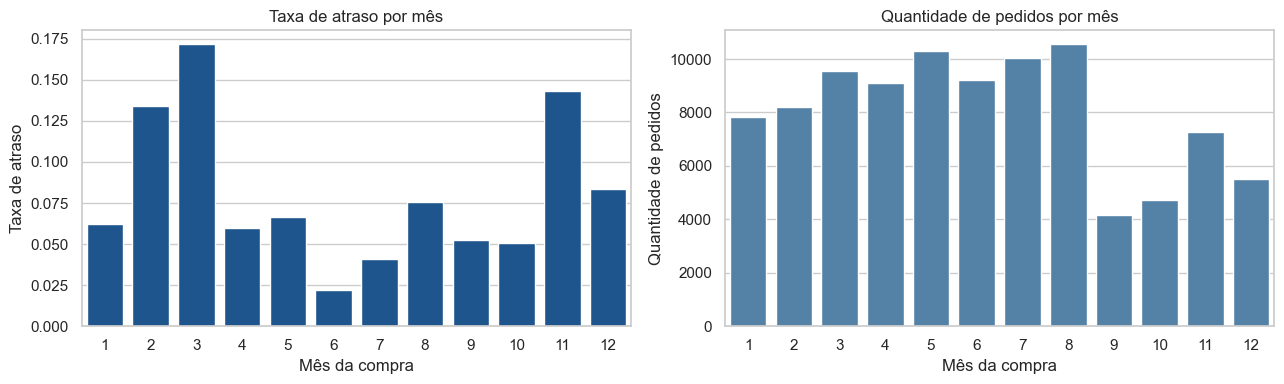

In [11]:
# Taxa de atraso e volume de pedidos por mês de compra.
q5 = orders_analysis.groupby("purchase_month")["is_late"].agg(taxa_atraso="mean", n_pedidos="size")
display(q5)

# Visualiza taxa de atraso e volume de pedidos lado a lado, para não confundir
# meses com poucos pedidos com meses realmente mais arriscados.
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

sns.barplot(data=q5.reset_index(), x="purchase_month", y="taxa_atraso", ax=axes[0])
axes[0].set_title("Taxa de atraso por mês")
axes[0].set_xlabel("Mês da compra")
axes[0].set_ylabel("Taxa de atraso")

sns.barplot(data=q5.reset_index(), x="purchase_month", y="n_pedidos", ax=axes[1], color="steelblue")
axes[1].set_title("Quantidade de pedidos por mês")
axes[1].set_xlabel("Mês da compra")
axes[1].set_ylabel("Quantidade de pedidos")

plt.tight_layout()
plt.show()

**Conclusão da pergunta 5:**

- Os meses com maior taxa de atraso são `março (17.2%)`, `novembro (14.3%)` e `fevereiro (13.4%)`, bem acima da média anual (`8.1%`).
- Novembro tem alto volume de pedidos (7.288, entre os maiores do ano) — consistente com pressão logística de Black Friday. Já março tem volume mediano (9.549), então o pico ali não parece ser só efeito de volume.
- Meses com menor taxa: `junho (2.2%)` e `julho (4.1%)`.
- Há indícios de sazonalidade, mas o padrão não é um crescimento suave ao longo do ano — parece concentrado em eventos/períodos específicos (novembro/Black Friday, início do ano). Vale cruzar com dados de mais de um ano antes de generalizar, já que este recorte cobre um período limitado.

# Pergunta 6: O dia da semana da compra está associado ao atraso?

**Hipótese:** compras feitas no fim de semana podem enfrentar mais atraso, já que a operação logística (armazéns, transportadoras) costuma ter capacidade reduzida aos sábados e domingos.

,taxa_atraso,n_pedidos
purchase_weekday,,
0,0.090504,15701
1,0.084892,15502
2,0.078015,15074
3,0.075698,14320
4,0.084497,13681
5,0.076041,10547
6,0.074886,11631


,taxa_atraso,n_pedidos
is_weekend,,
False,0.082837,74278
True,0.075435,22178


C:\Users\vitor\AppData\Local\Temp\ipykernel_25240\2781437888.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"])


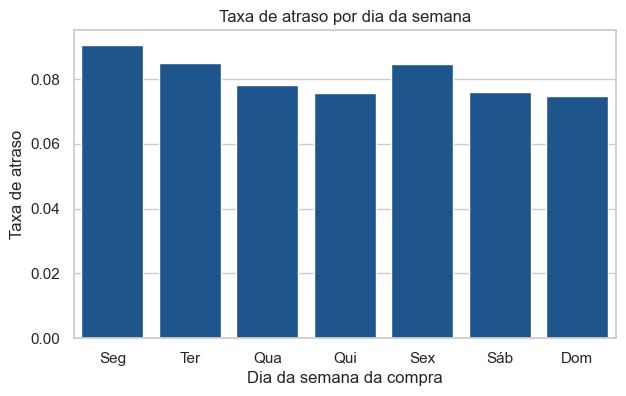

In [12]:
# Taxa de atraso por dia da semana (0 = segunda, 6 = domingo).
q6_weekday = orders_analysis.groupby("purchase_weekday")["is_late"].agg(taxa_atraso="mean", n_pedidos="size")
display(q6_weekday)

# Agrupa em dia de semana vs fim de semana para uma comparação mais direta.
orders_analysis["is_weekend"] = orders_analysis["purchase_weekday"].isin([5, 6])
q6_weekend = orders_analysis.groupby("is_weekend")["is_late"].agg(taxa_atraso="mean", n_pedidos="size")
display(q6_weekend)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=q6_weekday.reset_index(), x="purchase_weekday", y="taxa_atraso", ax=ax)
ax.set_xticklabels(["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"])
ax.set_xlabel("Dia da semana da compra")
ax.set_ylabel("Taxa de atraso")
ax.set_title("Taxa de atraso por dia da semana")
plt.show()

**Conclusão da pergunta 6:**

- A taxa de atraso varia pouco entre os dias da semana: de `7.5%` (quinta) a `9.1%` (segunda).
- Pedidos de fim de semana têm taxa de atraso um pouco **menor** (`7.5%`) que os de dia útil (`8.3%`) — o oposto do que a hipótese previa.
- A hipótese não foi apoiada. `purchase_weekday` isoladamente parece ter pouco poder discriminativo; não deve ser priorizado como feature relevante.

# Pergunta 7: O horário da compra está associado ao atraso?

**Hipótese:** compras feitas de madrugada podem ter o processamento/aprovação mais lento, empurrando o restante do fluxo logístico e aumentando o risco de atraso.

,taxa_atraso,n_pedidos
purchase_turno,,
madrugada,0.082081,4593
manhã,0.075584,21592
tarde,0.080928,37169
noite,0.084859,33102


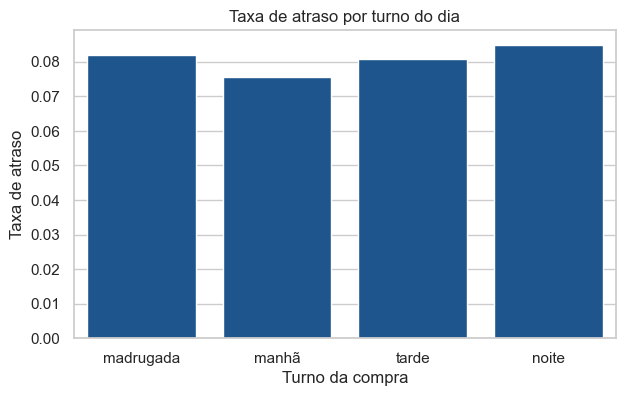

In [13]:
# Agrupa a hora da compra em turnos, para facilitar a leitura.
def turno_do_dia(hour):
    if 0 <= hour < 6:
        return "madrugada"
    if 6 <= hour < 12:
        return "manhã"
    if 12 <= hour < 18:
        return "tarde"
    return "noite"

orders_analysis["purchase_turno"] = orders_analysis["purchase_hour"].apply(turno_do_dia)

ordem_turnos = ["madrugada", "manhã", "tarde", "noite"]
q7 = (
    orders_analysis.groupby("purchase_turno")["is_late"]
    .agg(taxa_atraso="mean", n_pedidos="size")
    .reindex(ordem_turnos)
)
display(q7)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=q7.reset_index(), x="purchase_turno", y="taxa_atraso", order=ordem_turnos, ax=ax)
ax.set_xlabel("Turno da compra")
ax.set_ylabel("Taxa de atraso")
ax.set_title("Taxa de atraso por turno do dia")
plt.show()

**Conclusão da pergunta 7:**

- A taxa de atraso é praticamente igual entre turnos: `madrugada (8.2%)`, `manhã (7.6%)`, `tarde (8.1%)` e `noite (8.5%)`.
- A hipótese não foi apoiada — compras de madrugada não atrasam mais que as demais. A diferença entre o melhor e o pior turno é de menos de 1 ponto percentual, o que não parece operacionalmente relevante.
- `purchase_hour`/`purchase_turno` não parece ser uma feature promissora para o modelo de atraso.

# Pergunta 8: A proporção de frete sobre o valor do pedido está associada ao atraso?

**Hipótese:** um frete proporcionalmente caro em relação ao preço do produto (`freight_ratio = total_freight / total_price`) pode indicar maior distância ou complexidade logística, aumentando o risco de atraso.

,count,mean,std,min,25%,50%,75%,max
freight_ratio,96456.0,0.308395,0.311637,0.0,0.132017,0.224374,0.380585,21.447059


,taxa_atraso,n_pedidos
freight_ratio_q,,
Q1 (mais barato),0.082850,24116
Q2,0.077567,24134
Q3,0.081009,24096
Q4 (mais caro),0.083119,24110


Correlação freight_ratio x is_late: 0.006799133473866605


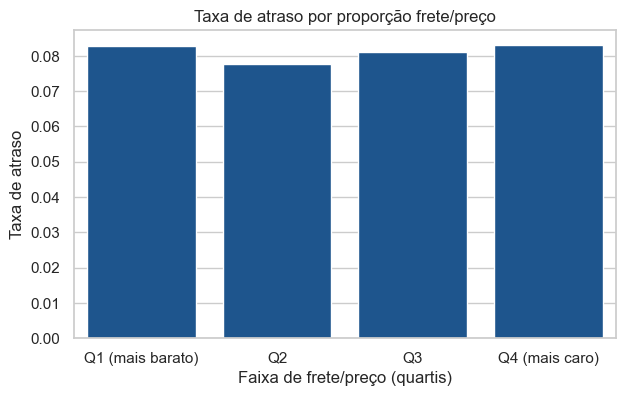

In [14]:
# Proporção entre frete total e valor total dos itens do pedido.
orders_analysis["freight_ratio"] = orders_analysis["total_freight"] / orders_analysis["total_price"]

display(orders_analysis["freight_ratio"].describe().to_frame().T)

# Divide em quartis para comparar a taxa de atraso entre pedidos com frete
# proporcionalmente mais barato e mais caro.
orders_analysis["freight_ratio_q"] = pd.qcut(
    orders_analysis["freight_ratio"], q=4, labels=["Q1 (mais barato)", "Q2", "Q3", "Q4 (mais caro)"]
)
q8 = orders_analysis.groupby("freight_ratio_q", observed=True)["is_late"].agg(
    taxa_atraso="mean", n_pedidos="size"
)
display(q8)

print("Correlação freight_ratio x is_late:", orders_analysis["freight_ratio"].corr(orders_analysis["is_late"]))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=q8.reset_index(), x="freight_ratio_q", y="taxa_atraso", ax=ax)
ax.set_xlabel("Faixa de frete/preço (quartis)")
ax.set_ylabel("Taxa de atraso")
ax.set_title("Taxa de atraso por proporção frete/preço")
plt.show()

**Conclusão da pergunta 8:**

- A taxa de atraso é quase idêntica entre os quartis de `freight_ratio`: de `7.8%` a `8.3%`.
- A correlação linear entre `freight_ratio` e `is_late` é praticamente nula (`0.007`).
- A hipótese não foi apoiada. O custo relativo do frete, isoladamente, não parece capturar risco de atraso — provavelmente porque o preço do frete reflete peso/distância de forma diferente do tempo real de trânsito, que já é parcialmente capturado por `promised_days` (pergunta 2) e `customer_state` (pergunta 4).